# SER - Exploratory Data Analysis

In [2]:
# built-in imports
import sys
import os
# src imports
module_path = os.path.abspath(os.path.join('..', '..')) 
sys.path.insert(0, module_path)
from src.data_loading import load_affectnet, load_ck, load_fer2013, load_rafbd, filter_emotions, load_iemocap
# 
import numpy as np
import pandas as pd

affect = filter_emotions(load_affectnet()) #load_affectnet()
ck = filter_emotions(load_ck()) #load_ck()
ck['pixels'] = ck['pixels'].apply(lambda x: np.array([int(p) for p in x.split(" ")]).reshape(48,48))
fer = filter_emotions(load_fer2013()) #load_fer2013()
fer['pixels'] = fer['pixels'].apply(lambda x: np.array([int(p) for p in x.split(" ")]).reshape(48,48))
raf = filter_emotions(load_rafbd()) #load_rafbd()

affect['dataset'] = 'affectnet'
ck['dataset'] = 'ck+'
fer['dataset'] = 'fer2013'
raf['dataset'] = 'rafdb'

iemocap = filter_emotions(load_iemocap())
iemocap.head()

Dataset downloaded to: /Users/sofiafernandes/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1
Available folders: ['happy', 'Contempt', 'sad', 'fear', 'surprise', 'neutral', 'Anger', 'disgust']


100%|██████████| 8/8 [00:12<00:00,  1.60s/it]


Subfolders in the dataset: ['ckextended.csv']
Subfolders in the dataset: ['fer2013.csv']
First few rows of the dataframe:
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training


100%|██████████| 37.7M/37.7M [00:02<00:00, 17.3MB/s]

Extracting model files...


Subfolders: ['train_labels.csv', 'test_labels.csv', 'DATASET']
Subfolders in the dataset: ['7', '6', '1', '4', '3', '2', '5']


100%|██████████| 3068/3068 [00:01<00:00, 2024.85it/s]


,session,method,gender,emotion,n_annotators,agreement,path,label,filename,utterance_id,transcription
0,1,script,F,neu,3,3,Session1/sentences/wav/Ses01F_script02_1/Ses01...,neutral,/Users/sofiafernandes/.cache/kagglehub/dataset...,Ses01F_script02_1_F000,Fine.
1,1,script,F,sur,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...,surprise,/Users/sofiafernandes/.cache/kagglehub/dataset...,Ses01F_script02_1_F003,What flashlight?
2,1,script,F,neu,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...,neutral,/Users/sofiafernandes/.cache/kagglehub/dataset...,Ses01F_script02_1_F004,That's not your flashlight.
3,1,script,F,ang,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...,angry,/Users/sofiafernandes/.cache/kagglehub/dataset...,Ses01F_script02_1_F006,You keep saying my flashlight like it's just y...
4,1,script,F,ang,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...,angry,/Users/sofiafernandes/.cache/kagglehub/dataset...,Ses01F_script02_1_F007,How's that supposed to make me feel?


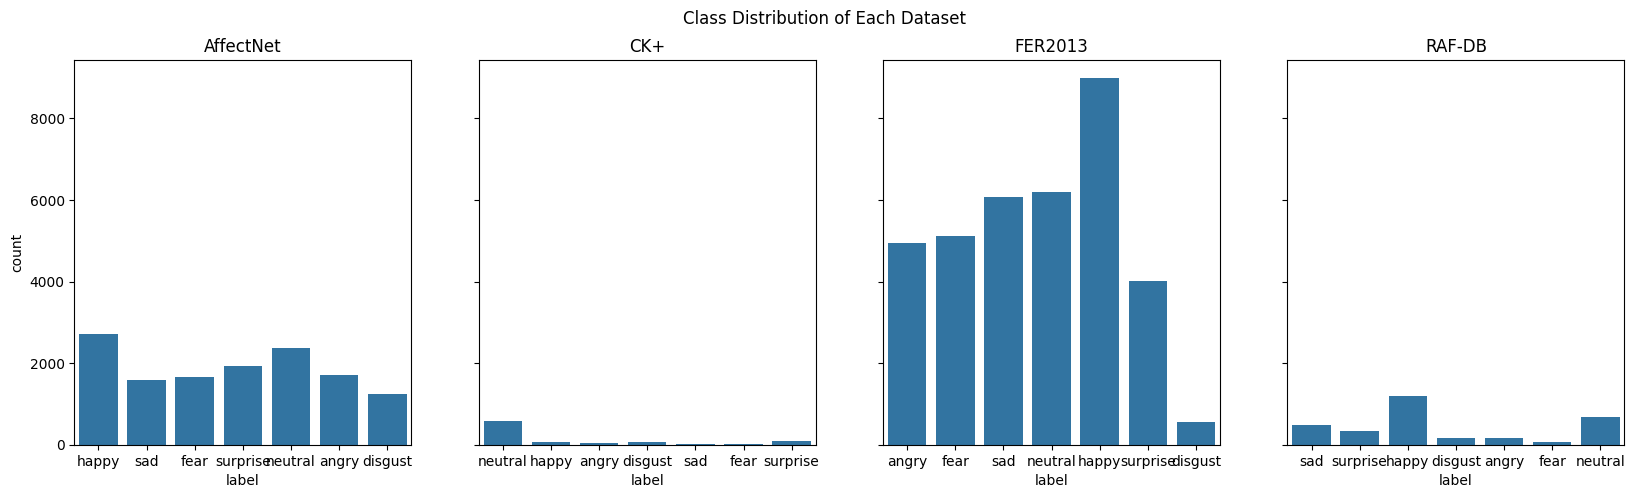

In [3]:
# plot class distribution of each dataset in a row of 4 subplots
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
sns.countplot(x='label', data=affect, ax=axes[0])
axes[0].set_title('AffectNet')
sns.countplot(x='label', data=ck, ax=axes[1])
axes[1].set_title('CK+')
sns.countplot(x='label', data=fer, ax=axes[2])
axes[2].set_title('FER2013')
sns.countplot(x='label', data=raf, ax=axes[3])
axes[3].set_title('RAF-DB')
plt.suptitle('Class Distribution of Each Dataset')
plt.savefig('countplot_fer.png')
plt.show()


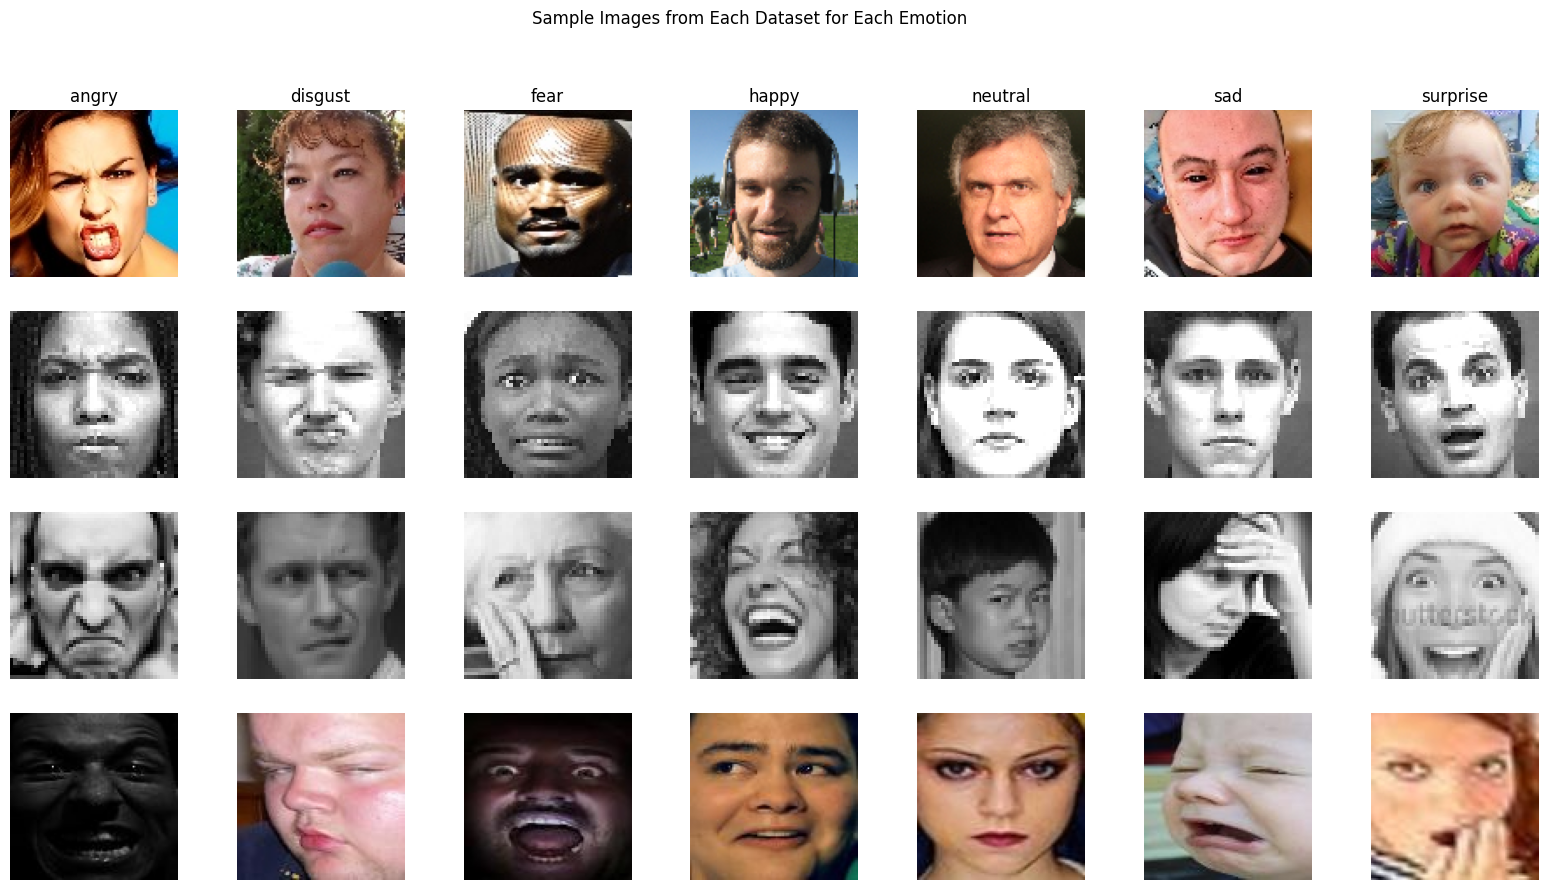

In [5]:
# plot an image from each dataset, for each emotion
fig, axes = plt.subplots(4, 7, figsize=(20, 10))
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
datasets = [affect, ck, fer, raf]   

for i, dataset in enumerate(datasets):
    for j, emotion in enumerate(emotions):
        img = dataset[dataset['label'] == emotion].sample(1)['pixels'].values[0]

        # Ensure uint8
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
        # Reshape if flat
        if len(img.shape) == 1:  
            side = int(np.sqrt(img.shape[0]))   # e.g. 48x48 for FER/CK+
            img = img.reshape(side, side)
        # Handle grayscale
        if len(img.shape) == 2:  # grayscale (48x48)
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)  # convert to 3-channel RGB
        #elif len(img.shape) == 3 and img.shape[2] == 3:  # already color
        elif dataset is affect:  # AffectNet is already color
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # BGR → RGB
        elif dataset is raf:  # RAF-DB is already RGB color
            img = img

        axes[i, j].imshow(img)
        axes[i, j].axis('off')

        if i == 0:
            axes[i, j].set_title(emotion, fontsize=12)
        if j == 0:
            if i == 0:
                axes[i, j].set_ylabel('AffectNet')
            elif i == 1:
                axes[i, j].set_ylabel('CK+')
            elif i == 2:
                axes[i, j].set_ylabel('FER2013')
            elif i == 3:
                axes[i, j].set_ylabel('RAF-DB')

plt.suptitle('Sample Images from Each Dataset for Each Emotion')
plt.savefig('sample_images_fer.png')
plt.show()


4it [00:07,  1.76s/it]


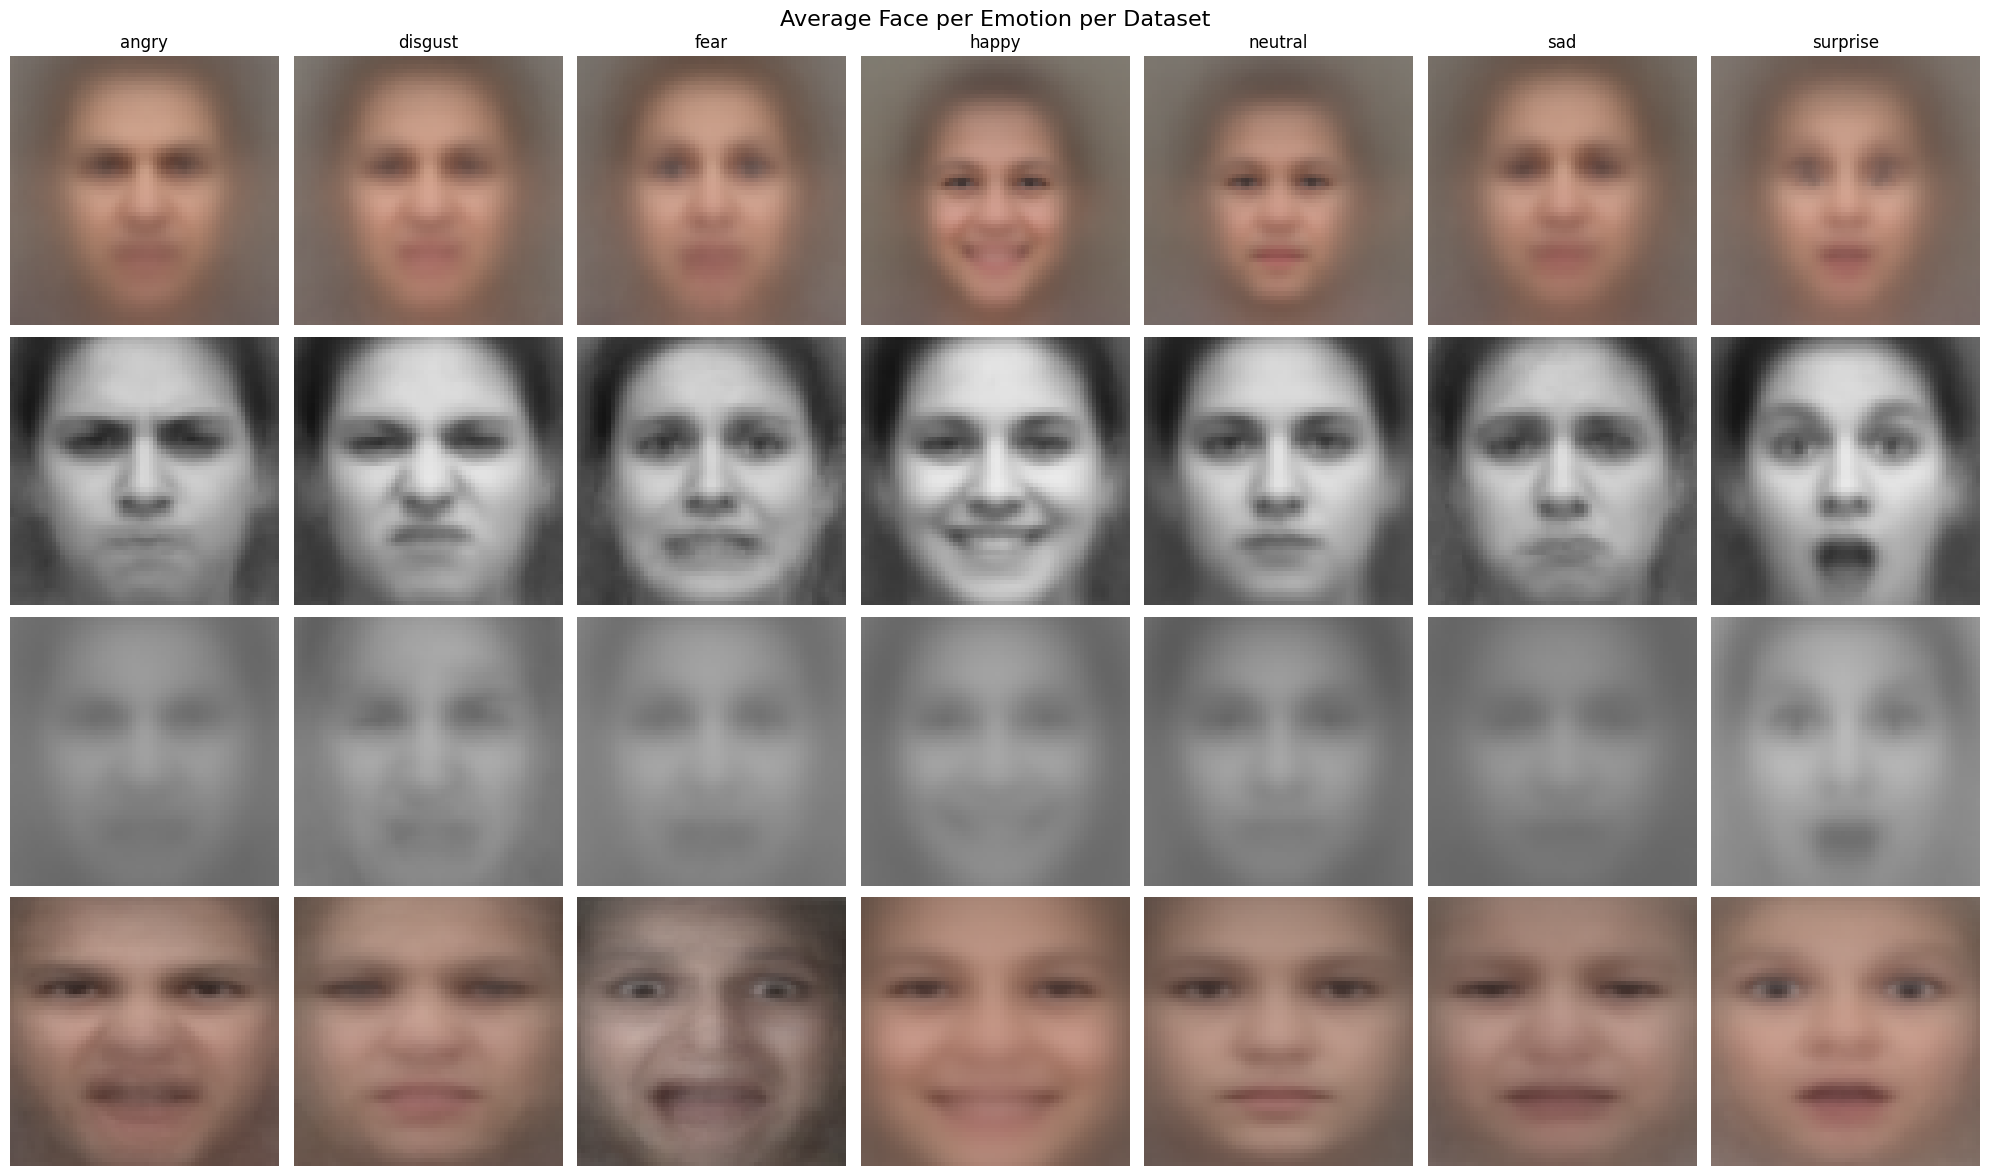

In [67]:
from tqdm import tqdm
tqdm.pandas()
# plot average image for each emotion per dataset (rows = datasets, cols = emotions)
fig, axes = plt.subplots(len([affect, ck, fer, raf]), 7, figsize=(20, 12))
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
datasets = [affect, ck, fer, raf]
dataset_names = ['AffectNet', 'CK+', 'FER2013', 'RAF-DB']

target_size = (64, 64)  # common size for averaging

for i, dataset in tqdm(enumerate(datasets)):
    for j, emotion in enumerate(emotions):
        imgs = dataset[dataset['label'] == emotion]['pixels'].values
        
        processed_imgs = []
        for img in imgs:
            # Convert to uint8
            if img.dtype != np.uint8:
                img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)

            # Reshape if flat
            if len(img.shape) == 1:
                side = int(np.sqrt(img.shape[0]))  # e.g. 48x48
                img = img.reshape(side, side)

            # Handle grayscale
            if len(img.shape) == 2:  # grayscale (48x48)
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)  # convert to 3-channel RGB
            #elif len(img.shape) == 3 and img.shape[2] == 3:  # already color
            elif dataset is affect:  # AffectNet is already color
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # BGR → RGB
            elif dataset is raf:  # RAF-DB is already RGB color
                img = img

            # Resize to target size
            img = cv2.resize(img, target_size)

            processed_imgs.append(img.astype(np.float32))  # for averaging

        if processed_imgs:
            avg_img = np.mean(processed_imgs, axis=0)
            # error face from mean (difference from mean)
            #mean_face = np.mean(processed_imgs, axis=0)
            #diffs = [np.abs(img - mean_face) for img in processed_imgs]
            #std_diffs = [np.square(img - mean_face) for img in processed_imgs]
            #diffs = [np.sqrt(np.mean(d, axis=-1)) for d in std_diffs]
            #avg_img = np.mean(diffs, axis=0)
            axes[i, j].imshow(avg_img.astype(np.uint8))
        else:
            axes[i, j].imshow(np.zeros((target_size[0], target_size[1], 3), dtype=np.uint8))  # empty placeholder

        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(emotions[j], fontsize=12)
    axes[i, 0].set_ylabel(dataset_names[i], fontsize=12)

plt.suptitle("Average Face per Emotion per Dataset", fontsize=16)
plt.tight_layout()
plt.savefig('average_faces_fer.png')
plt.show()


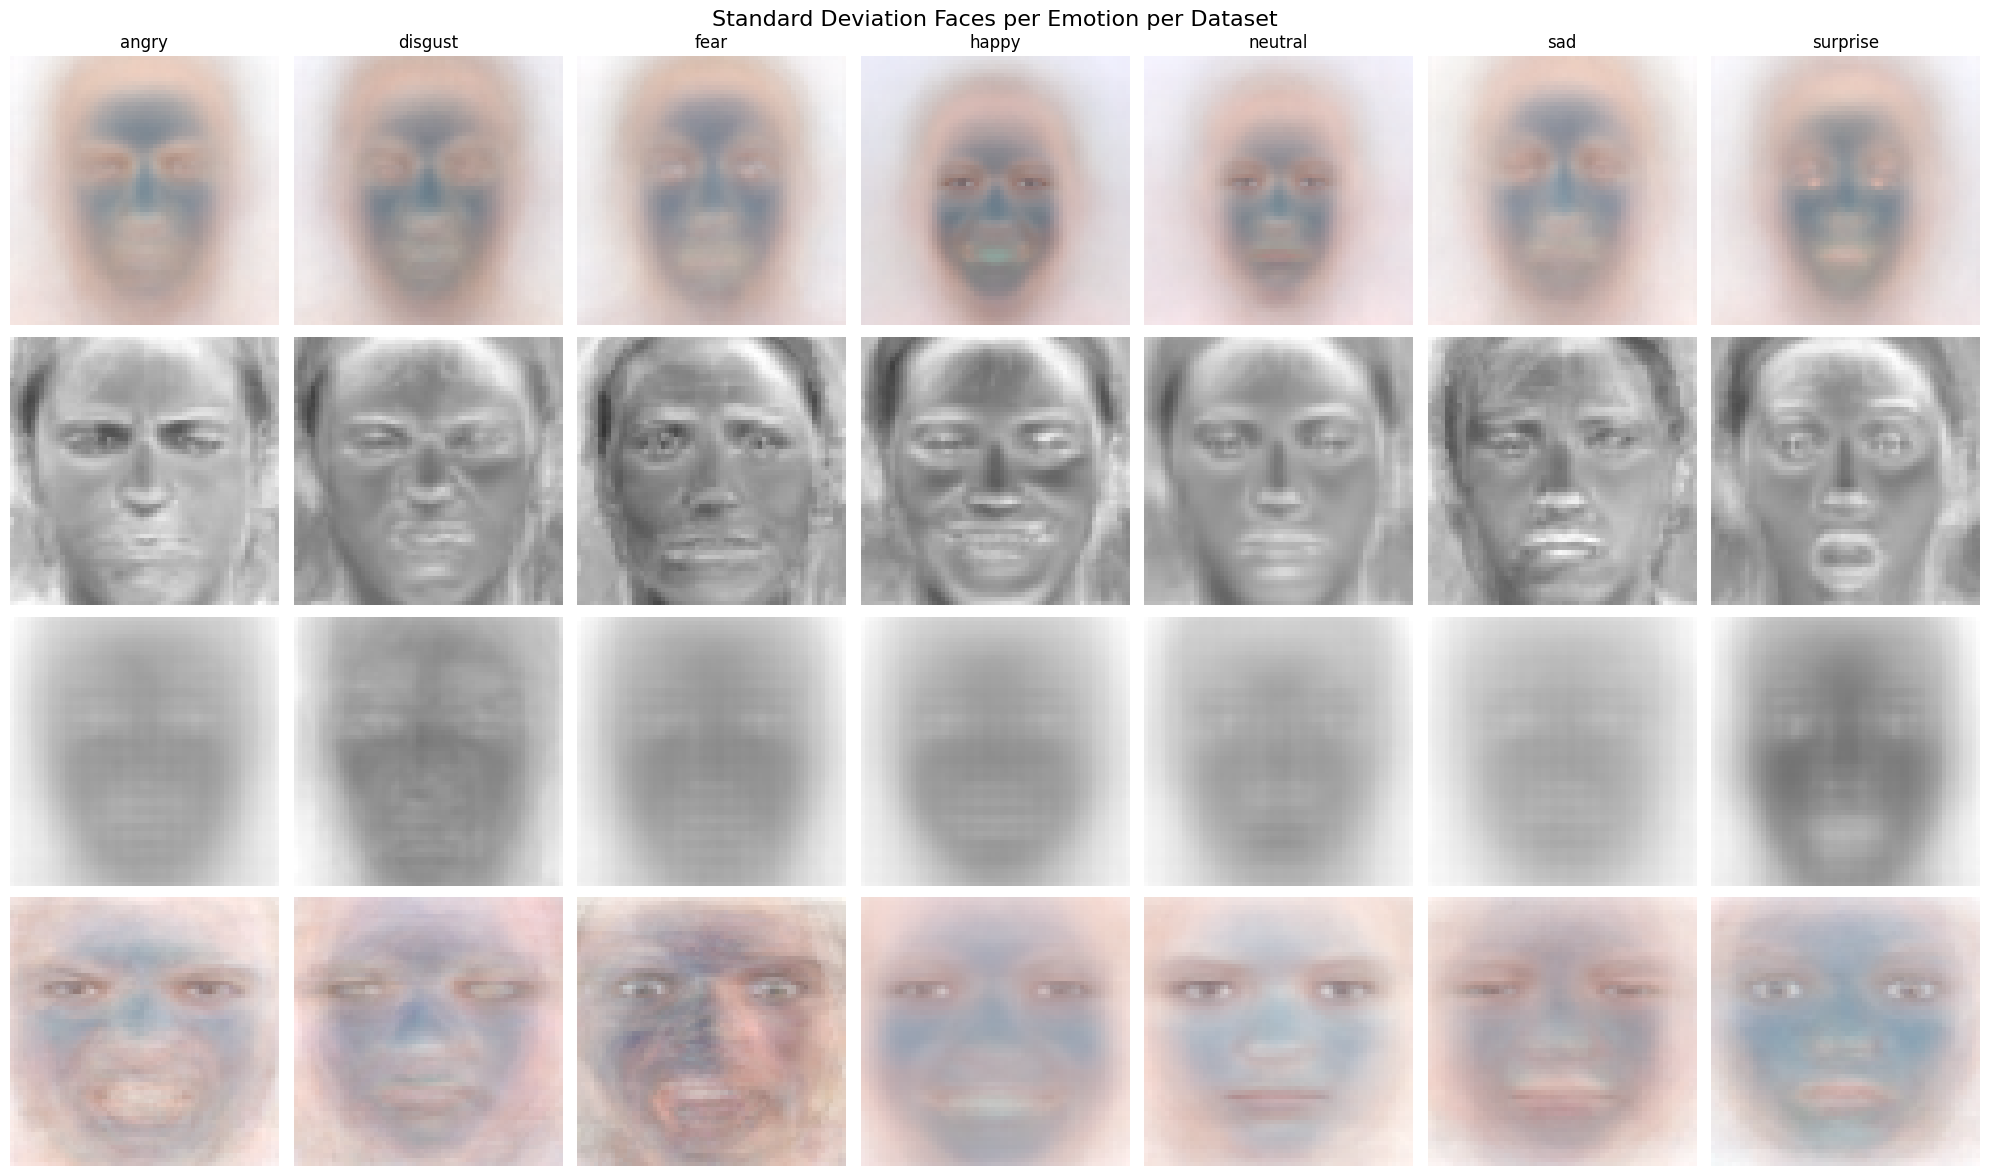

In [53]:
# plot standard deviation image for each emotion per dataset
fig, axes = plt.subplots(len(datasets), len(emotions), figsize=(20, 12))

for i, dataset in enumerate(datasets):
    for j, emotion in enumerate(emotions):
        imgs = dataset[dataset['label'] == emotion]['pixels'].values
        processed_imgs = []
        
        for img in imgs:
            if img.dtype != np.uint8:
                img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
            if len(img.shape) == 1:  # flat vector
                side = int(np.sqrt(img.shape[0]))
                img = img.reshape(side, side)
            if len(img.shape) == 2:  # grayscale
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            elif dataset is affect:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, target_size)
            processed_imgs.append(img.astype(np.float32))

        if processed_imgs:
            std_img = np.std(processed_imgs, axis=0)
            std_img = (std_img / std_img.max() * 255).astype(np.uint8)  # normalize for visibility
            axes[i, j].imshow(std_img)
        else:
            axes[i, j].imshow(np.zeros((target_size[0], target_size[1], 3), dtype=np.uint8))

        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(emotions[j])
    axes[i, 0].set_ylabel(dataset_names[i], fontsize=12)

plt.suptitle("Standard Deviation Faces per Emotion per Dataset", fontsize=16)
plt.tight_layout()
plt.savefig('std_faces_fer.png')
plt.show()


4it [00:07,  1.95s/it]


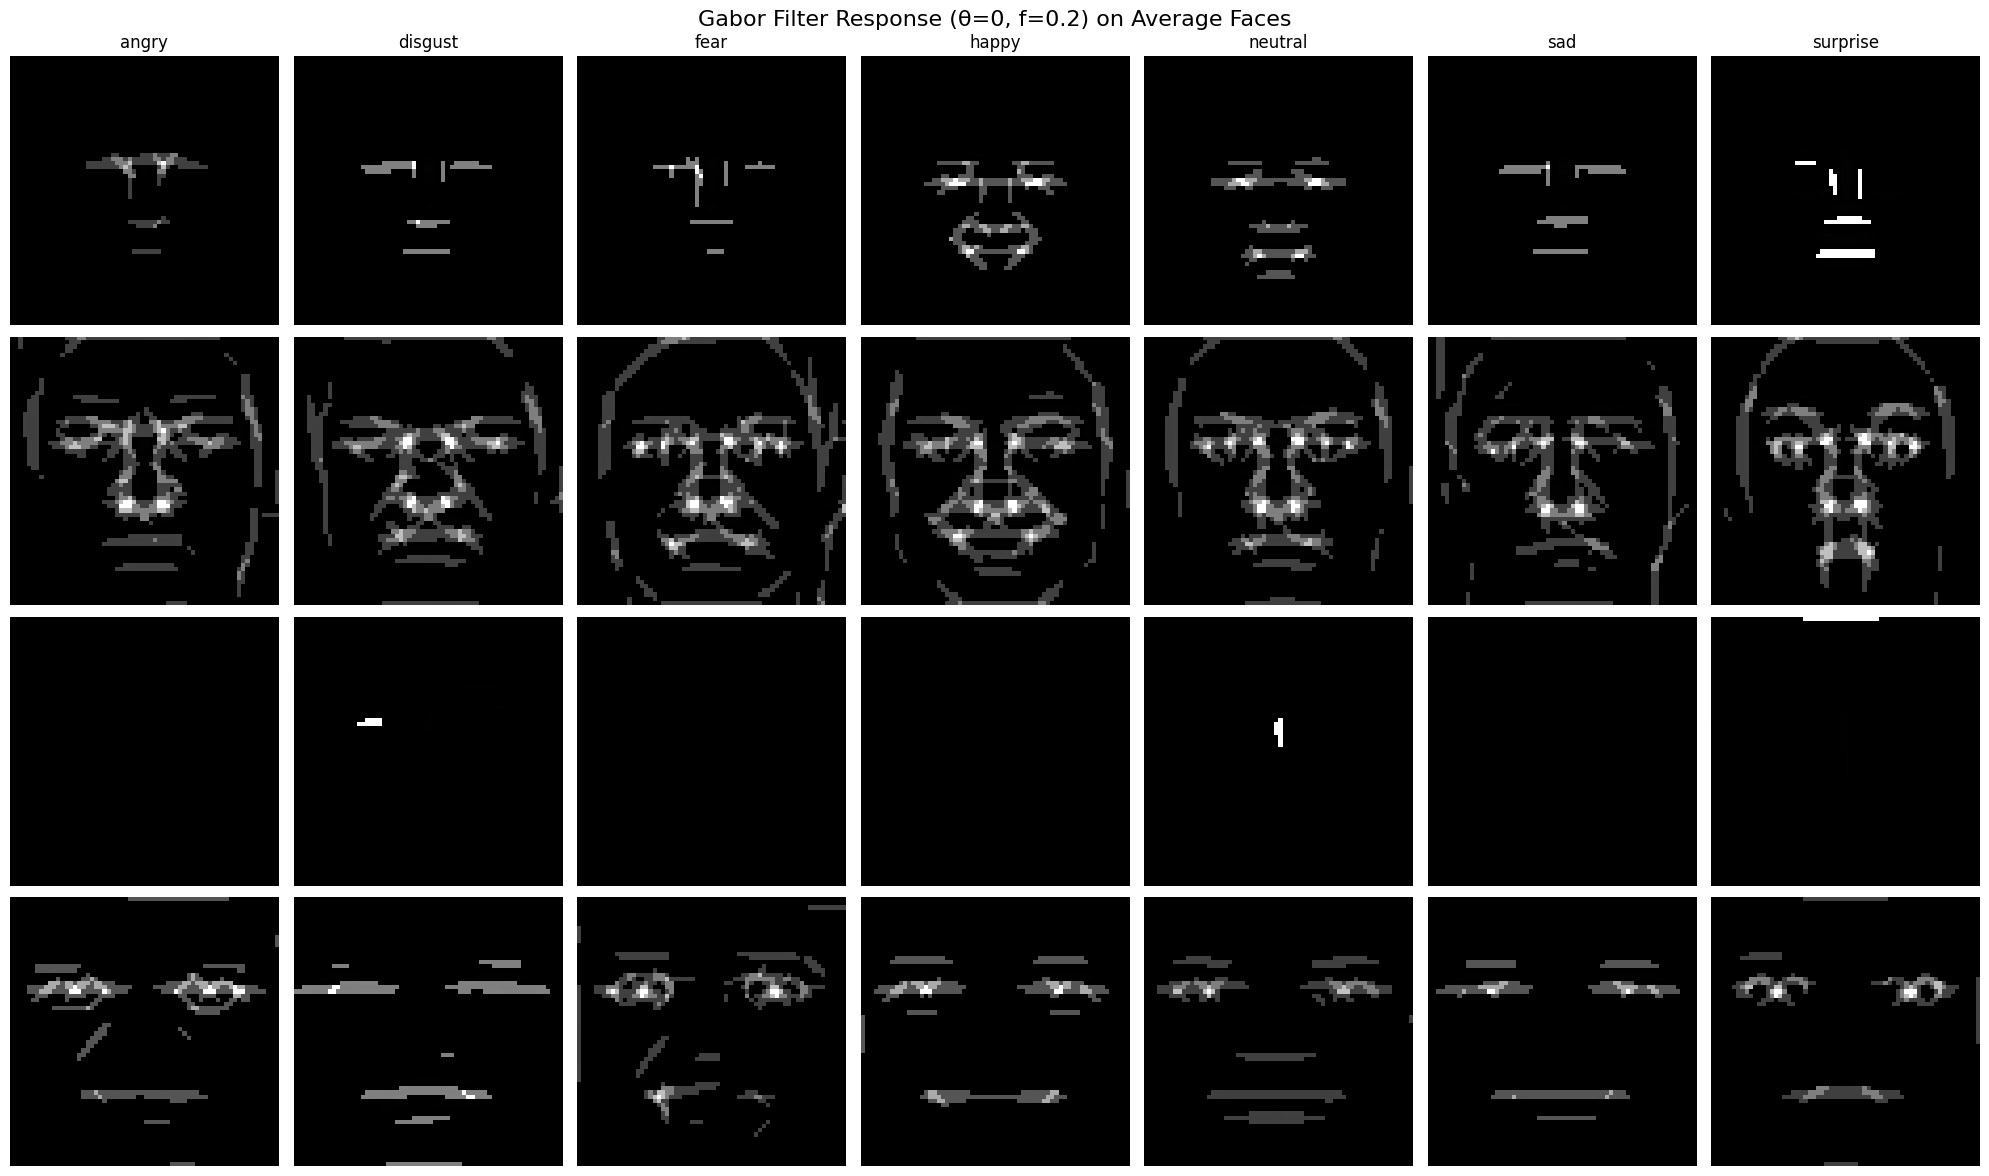

In [51]:
from skimage.filters import gabor

# Parameters for Gabor (you can vary frequency and theta to create a filter bank)
frequency = 0.2   # spatial frequency, try 0.1–0.4
theta = 0         # orientation (radians), try 0, π/4, π/2, etc.

fig, axes = plt.subplots(len(datasets), len(emotions), figsize=(20, 12))
for i, dataset in tqdm(enumerate(datasets)):
    for j, emotion in enumerate(emotions):
        imgs = dataset[dataset['label'] == emotion]['pixels'].values

        processed_imgs = []
        for img in imgs:
            if img.dtype != np.uint8:
                img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
            if len(img.shape) == 1:
                side = int(np.sqrt(img.shape[0]))
                img = img.reshape(side, side)
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            elif dataset is affect:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            elif dataset is raf:
                img = img
            img = cv2.resize(img, target_size)
            processed_imgs.append(img.astype(np.float32))

        if processed_imgs:
            avg_img = np.mean(processed_imgs, axis=0).astype(np.uint8)
            gray_avg = cv2.cvtColor(avg_img, cv2.COLOR_RGB2GRAY)

            orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
            frequency = 0.2 #0.2
            responses = [gabor(gray_avg, frequency=frequency, theta=theta)[0] for theta in orientations]

            gabor_response = np.sum(np.array(responses), axis=0)
            #gabor_response = (gabor_response - gabor_response.min()) / (gabor_response.max() - gabor_response.min())
            eps = 1e-8  # small value to avoid division by zero
            gabor_response = (gabor_response - gabor_response.min()) / (gabor_response.max() - gabor_response.min() + eps)

            axes[i, j].imshow(gabor_response, cmap='gray')
        else:
            axes[i, j].imshow(np.zeros(target_size, dtype=np.uint8), cmap="gray")

        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(emotions[j], fontsize=12)
    axes[i, 0].set_ylabel(dataset_names[i], fontsize=12)

plt.suptitle("Gabor Filter Response (θ=0, f=0.2) on Average Faces", fontsize=16)
plt.tight_layout()
plt.savefig("gabor_avg_faces.png")
plt.show()


4it [00:03,  1.13it/s]


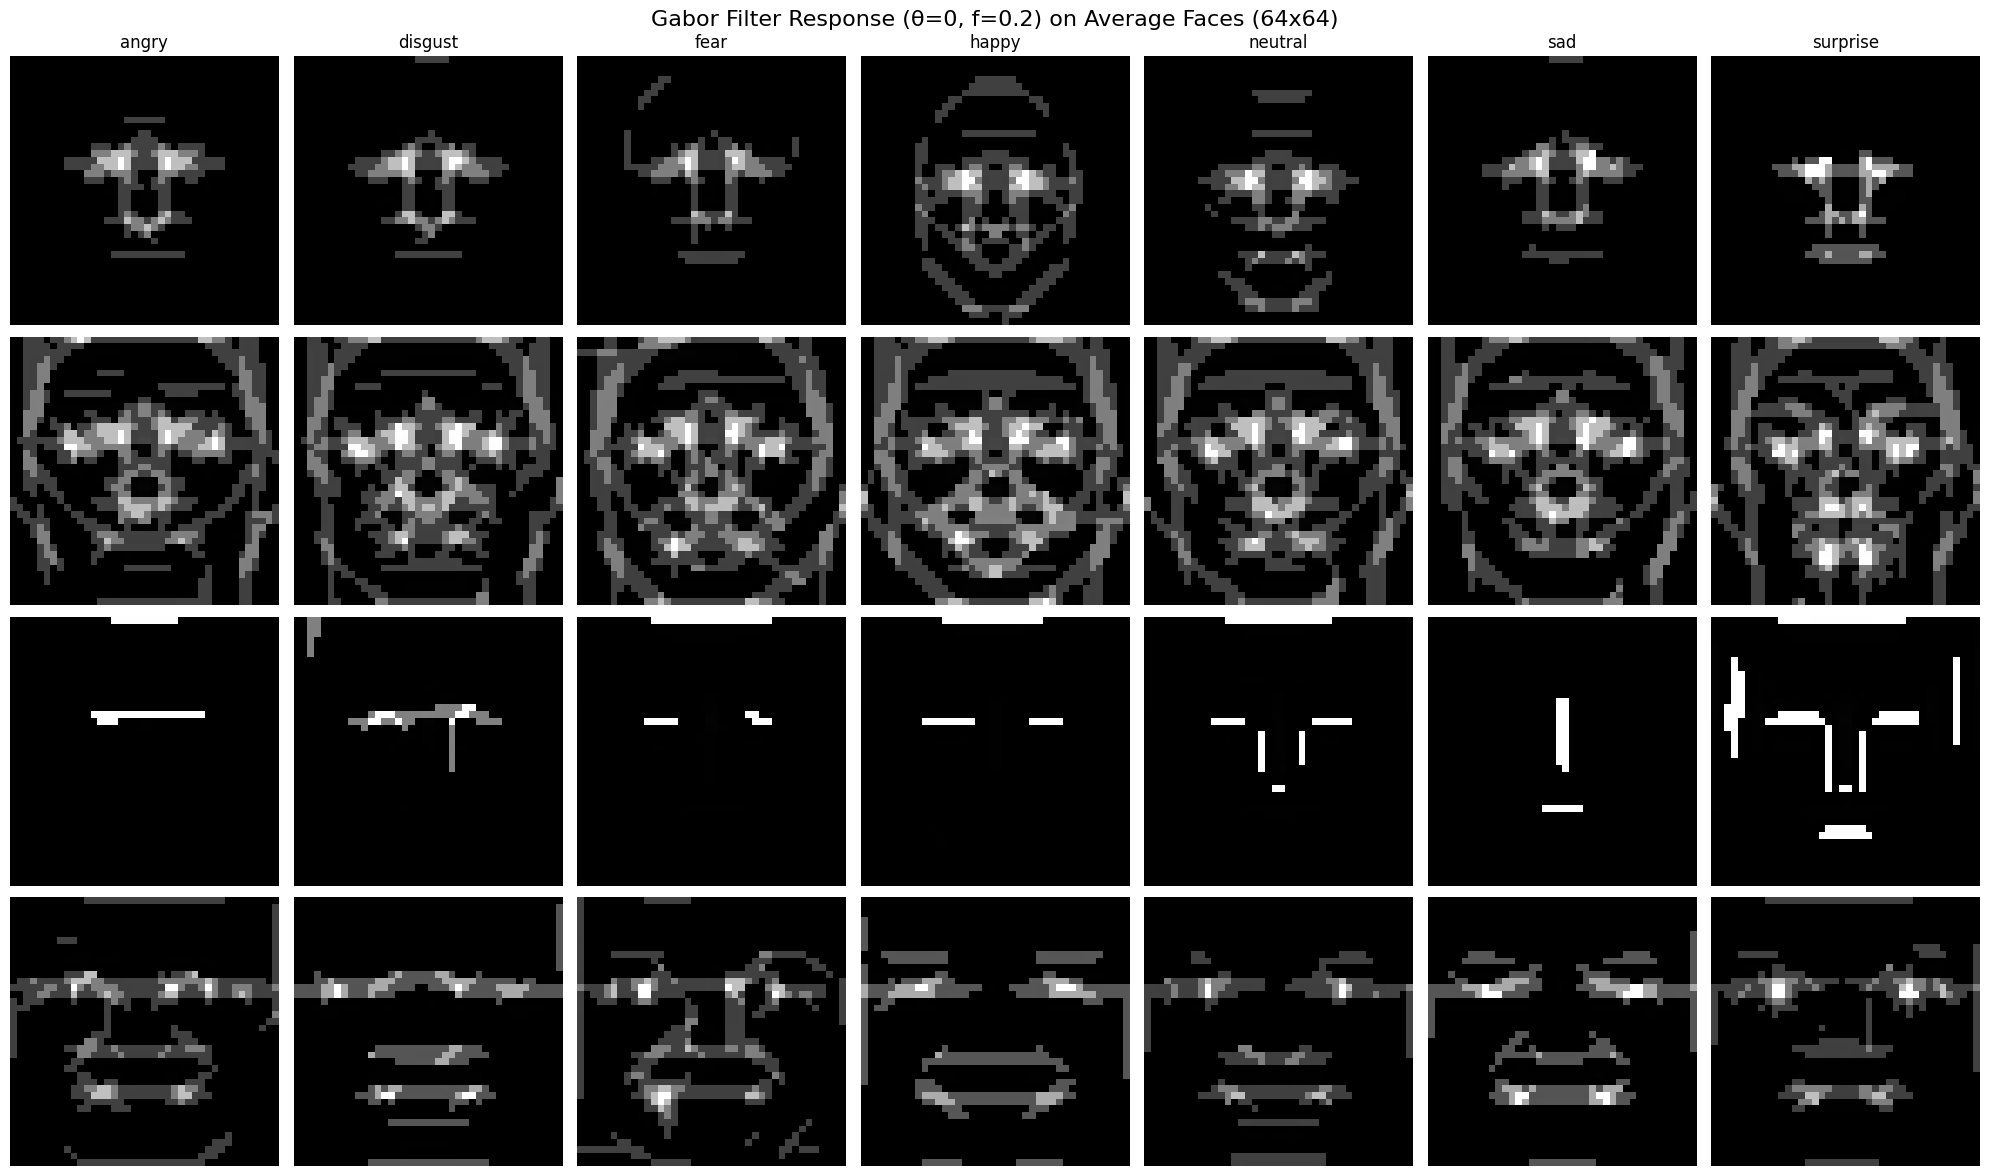

In [62]:
from skimage.filters import gabor
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Fixed target size
target_size = (40, 40)

# Parameters for Gabor
frequency = 0.2
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]

fig, axes = plt.subplots(len(datasets), len(emotions), figsize=(20, 12))

for i, dataset in tqdm(enumerate(datasets)):
    for j, emotion in enumerate(emotions):
        imgs = dataset[dataset['label'] == emotion]['pixels'].values

        processed_imgs = []
        for img in imgs:
            # Convert to uint8
            if img.dtype != np.uint8:
                img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
            # Reshape if flat
            if len(img.shape) == 1:
                side = int(np.sqrt(img.shape[0]))
                img = img.reshape(side, side)
            # Convert grayscale to RGB
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            elif dataset is affect:  # AffectNet is BGR
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            elif dataset is raf:     # RAF-DB already RGB
                img = img
            # Resize to fixed target size
            img = cv2.resize(img, target_size)
            processed_imgs.append(img.astype(np.float32))

        if processed_imgs:
            avg_img = np.mean(processed_imgs, axis=0).astype(np.uint8)
            gray_avg = cv2.cvtColor(avg_img, cv2.COLOR_RGB2GRAY)

            responses = [gabor(gray_avg, frequency=frequency, theta=theta)[0] for theta in orientations]
            gabor_response = np.sum(np.array(responses), axis=0)

            # Normalize
            eps = 1e-8
            gabor_response = (gabor_response - gabor_response.min()) / (gabor_response.max() - gabor_response.min() + eps)

            axes[i, j].imshow(gabor_response, cmap='gray')
        else:
            axes[i, j].imshow(np.zeros(target_size, dtype=np.uint8), cmap="gray")

        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(emotions[j], fontsize=12)
    axes[i, 0].set_ylabel(dataset_names[i], fontsize=12)

plt.suptitle("Gabor Filter Response (θ=0, f=0.2) on Average Faces (64x64)", fontsize=16)
plt.tight_layout()
plt.savefig("gabor_avg_faces_64.png")
plt.show()


4it [00:07,  1.98s/it]


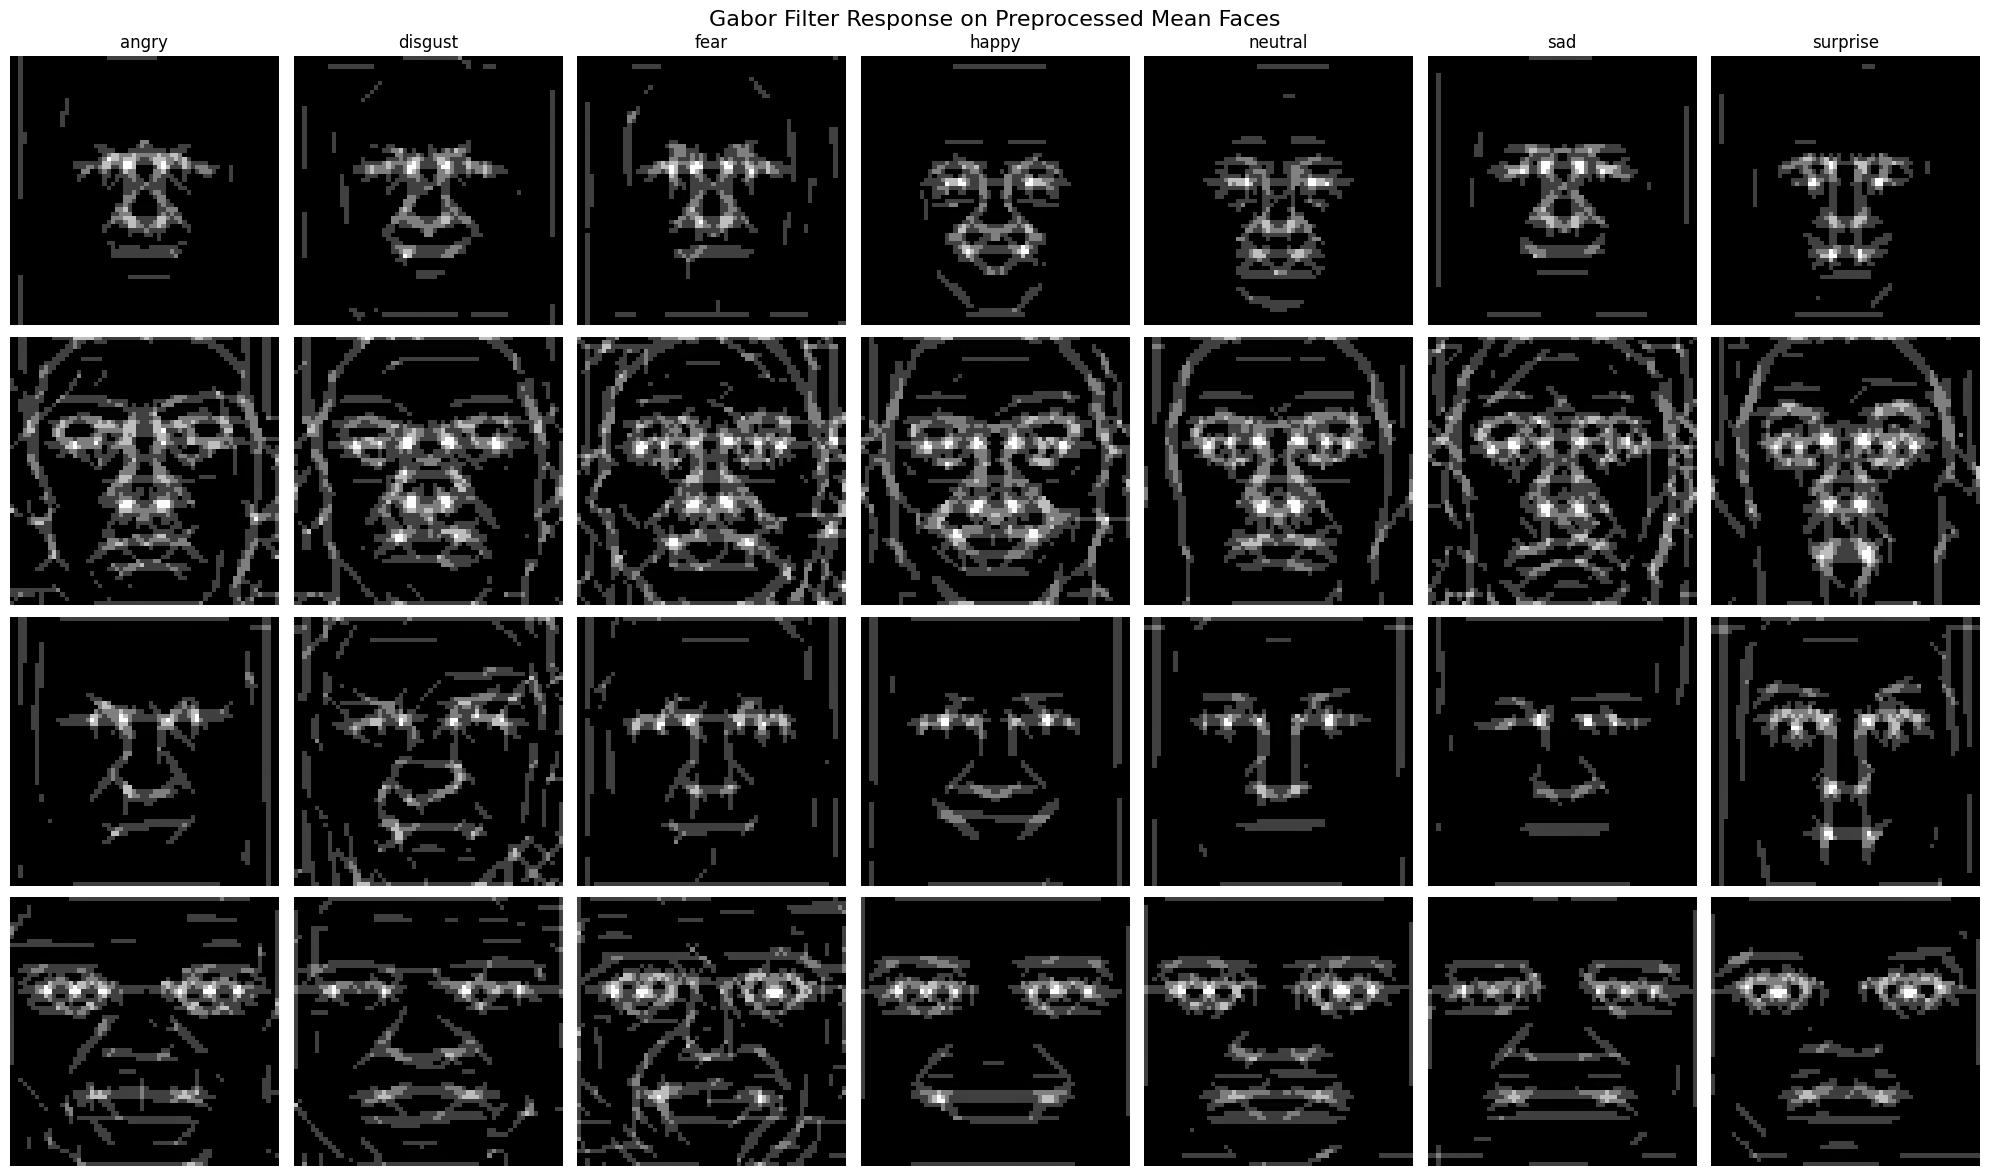

In [59]:
from skimage.filters import gabor
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

# Preprocessing function for computing average face
def preprocess_mean_face(imgs, target_size=(64,64), sharpen_method=None):
    processed_imgs = []
    for img in imgs:
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
        if len(img.shape) == 1:
            side = int(np.sqrt(img.shape[0]))
            img = img.reshape(side, side)
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, target_size)
        processed_imgs.append(img.astype(np.float32))
    
    if not processed_imgs:
        return np.zeros((target_size[0], target_size[1], 3), dtype=np.float32)
    
    avg_img = np.mean(processed_imgs, axis=0)

    # Optional sharpening
    if sharpen_method:
        if sharpen_method == 'unsharp':
            blur = cv2.GaussianBlur(avg_img, (3,3), 0)
            avg_img = cv2.addWeighted(avg_img, 1.5, blur, -0.5, 0)
        elif sharpen_method == 'kernel':
            kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
            avg_img = cv2.filter2D(avg_img, -1, kernel)
        elif sharpen_method == 'highpass':
            high_pass = avg_img - cv2.GaussianBlur(avg_img, (3,3), 0)
            avg_img = cv2.add(avg_img, high_pass)

    avg_img = (avg_img - avg_img.min()) / (avg_img.max() - avg_img.min() + 1e-8) * 255
    return avg_img.astype(np.uint8)

# Plot Gabor responses on preprocessed mean faces
fig, axes = plt.subplots(len(datasets), len(emotions), figsize=(20,12))
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
frequency = 0.2  # Gabor frequency

for i, dataset in tqdm(enumerate(datasets)):
    for j, emotion in enumerate(emotions):
        imgs = dataset[dataset['label'] == emotion]['pixels'].values
        avg_img = preprocess_mean_face(imgs, target_size=(64,64), sharpen_method='kernel')
        gray_avg = cv2.cvtColor(avg_img, cv2.COLOR_RGB2GRAY)

        # Compute Gabor responses for multiple orientations
        responses = [gabor(gray_avg, frequency=frequency, theta=theta)[0] for theta in orientations]
        gabor_response = np.sum(np.array(responses), axis=0)

        # Normalize
        gabor_response = (gabor_response - gabor_response.min()) / (gabor_response.max() - gabor_response.min() + 1e-8)
        axes[i,j].imshow(gabor_response, cmap='gray')
        axes[i,j].axis('off')
        if i == 0:
            axes[i,j].set_title(emotion)
    axes[i,0].set_ylabel(dataset_names[i])

plt.suptitle("Gabor Filter Response on Preprocessed Mean Faces", fontsize=16)
plt.tight_layout()
plt.savefig("gabor_kernel_mean_faces.png")
plt.show()


4it [00:08,  2.04s/it]


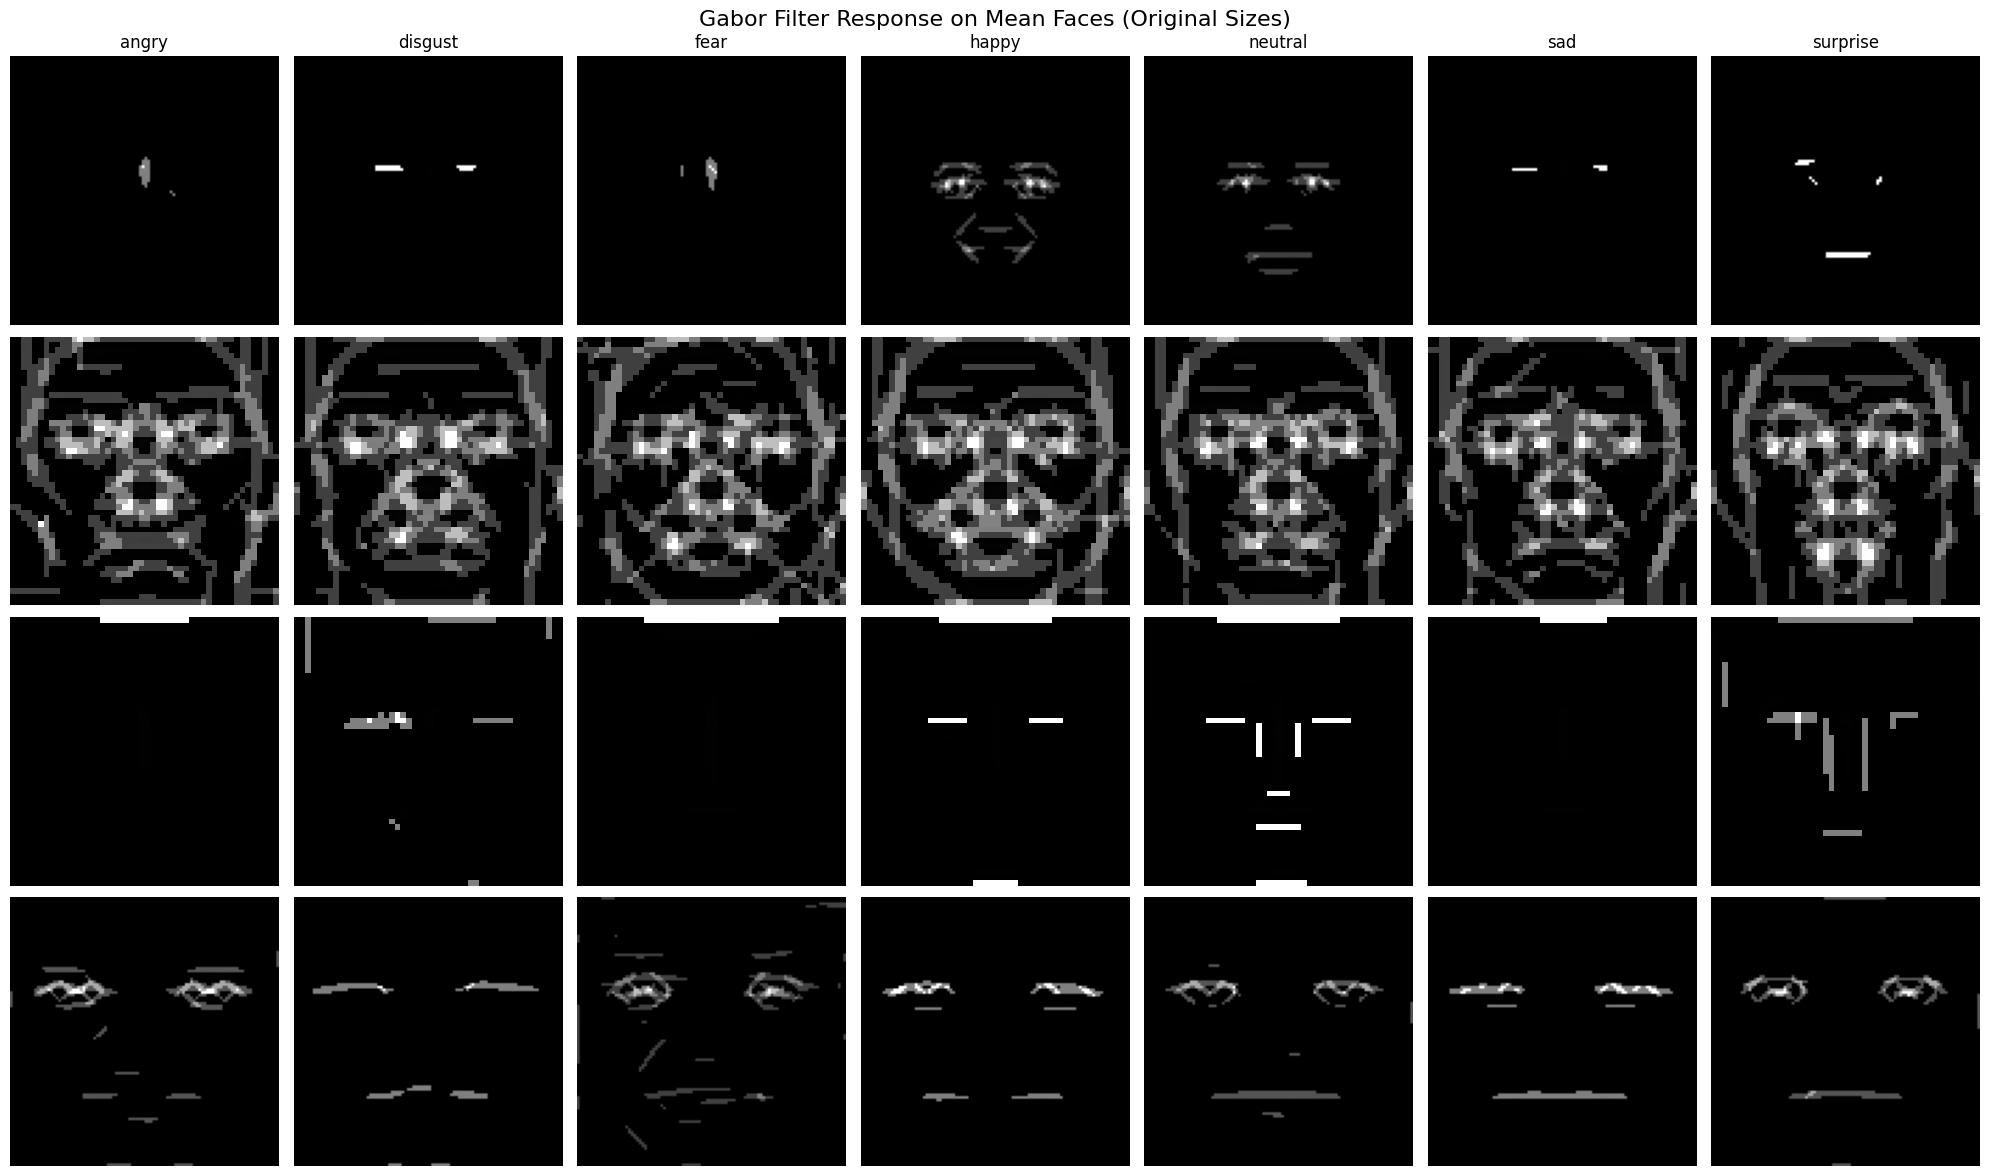

In [60]:
from skimage.filters import gabor
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

def preprocess_and_gabor_mean_face(imgs, sharpen_method=None):
    """
    Preprocess images, compute mean face, apply optional sharpening, return grayscale mean face.
    Automatically determines target_size from the first image.
    
    sharpen_method: None | 'unsharp' | 'kernel' | 'highpass'
    """
    if len(imgs) == 0:
        return np.zeros((48,48), dtype=np.uint8)  # default small placeholder
    
    # Determine target size from the first image
    first_img = imgs[0]
    if len(first_img.shape) == 1:
        side = int(np.sqrt(first_img.shape[0]))
        target_size = (side, side)
    else:
        target_size = first_img.shape[:2]
    
    processed_imgs = []
    for img in imgs:
        # Convert to uint8
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
        # Reshape if flat
        if len(img.shape) == 1:
            side = int(np.sqrt(img.shape[0]))
            img = img.reshape(side, side)
        # Grayscale → RGB
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Resize to target size of first image
        img = cv2.resize(img, target_size)
        processed_imgs.append(img.astype(np.float32))
    
    # Compute mean face
    avg_img = np.mean(processed_imgs, axis=0)
    
    # Apply sharpening if needed
    if sharpen_method:
        if sharpen_method == 'unsharp':
            blur = cv2.GaussianBlur(avg_img, (3, 3), 0)
            avg_img = cv2.addWeighted(avg_img, 1.5, blur, -0.5, 0)
        elif sharpen_method == 'kernel':
            kernel = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])
            avg_img = cv2.filter2D(avg_img, -1, kernel)
        elif sharpen_method == 'highpass':
            high_pass = avg_img - cv2.GaussianBlur(avg_img, (3,3), 0)
            avg_img = cv2.add(avg_img, high_pass)
    
    # Convert mean face to grayscale
    gray_avg = cv2.cvtColor(avg_img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    return gray_avg, target_size

# Example: plot Gabor response for mean faces per emotion per dataset
fig, axes = plt.subplots(len(datasets), len(emotions), figsize=(20,12))

for i, dataset in tqdm(enumerate(datasets)):
    for j, emotion in enumerate(emotions):
        imgs = dataset[dataset['label'] == emotion]['pixels'].values
        gray_avg, target_size = preprocess_and_gabor_mean_face(imgs, sharpen_method='highpass')
        
        # Gabor filter bank
        orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
        frequency = 0.2
        responses = [gabor(gray_avg, frequency=frequency, theta=theta)[0] for theta in orientations]
        gabor_response = np.sum(np.array(responses), axis=0)
        
        # Normalize
        eps = 1e-8
        gabor_response = (gabor_response - gabor_response.min()) / (gabor_response.max() - gabor_response.min() + eps)
        
        axes[i,j].imshow(gabor_response, cmap='gray')
        axes[i,j].axis('off')
        if i == 0:
            axes[i,j].set_title(emotions[j])
    axes[i,0].set_ylabel(dataset_names[i])

plt.suptitle("Gabor Filter Response on Mean Faces (Original Sizes)", fontsize=16)
plt.tight_layout()
plt.show()


4it [00:07,  1.84s/it]


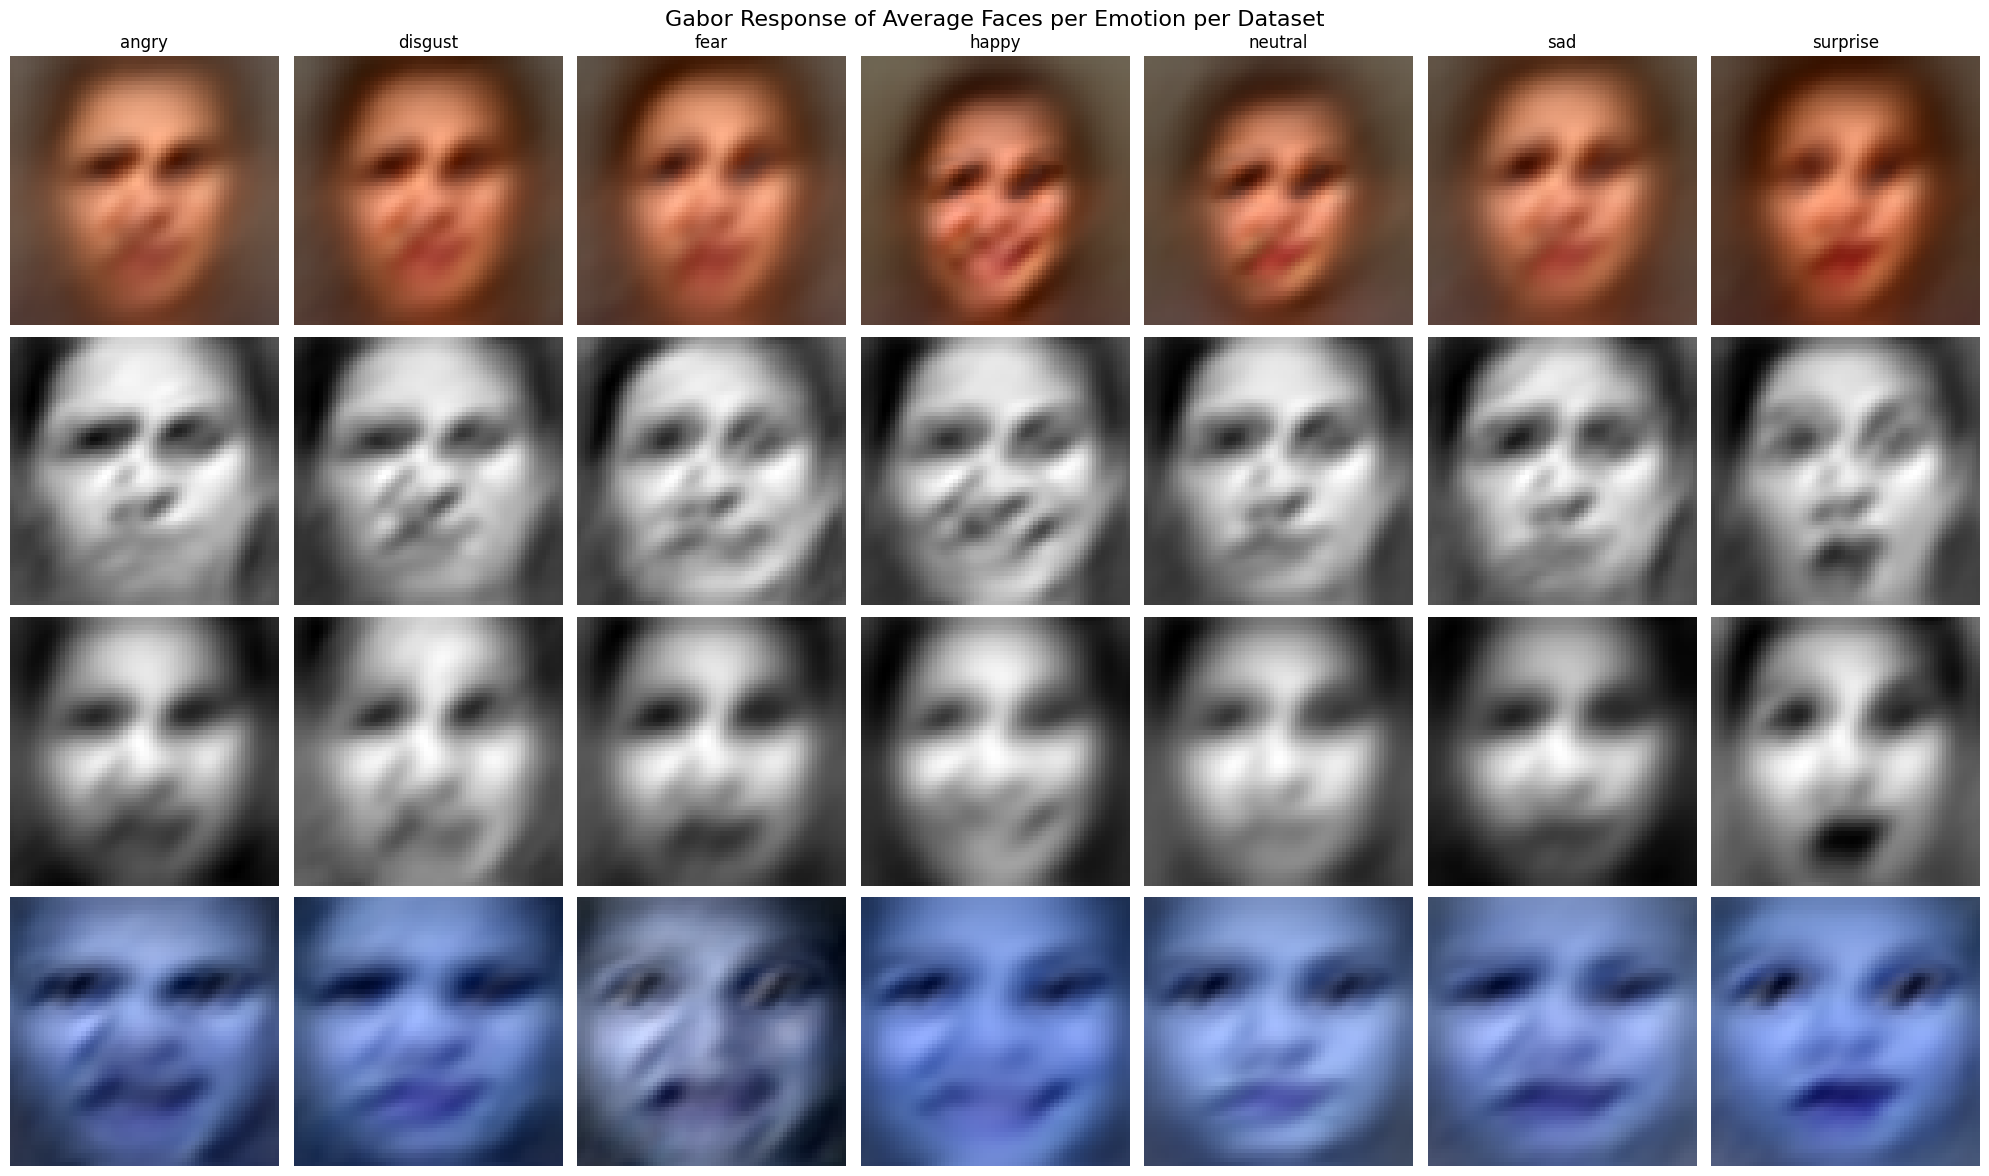

In [55]:
import cv2
import numpy as np
from tqdm import tqdm

def preprocess_and_gabor(imgs, target_size=(64,64), sharpen_method=None):
    """
    Preprocess images, compute average face, apply optional sharpening, and return for Gabor filtering.
    
    sharpen_method: None | 'unsharp' | 'kernel' | 'highpass'
    """
    processed_imgs = []
    for img in imgs:
        # Convert to uint8
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
        # Reshape if flat
        if len(img.shape) == 1:
            side = int(np.sqrt(img.shape[0]))
            img = img.reshape(side, side)
        # Grayscale → RGB
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Resize
        img = cv2.resize(img, target_size)
        processed_imgs.append(img.astype(np.float32))
    
    if not processed_imgs:
        return np.zeros((target_size[0], target_size[1], 3), dtype=np.float32)
    
    avg_img = np.mean(processed_imgs, axis=0)
    
    # Apply sharpening
    if sharpen_method:
        if sharpen_method == 'unsharp':
            blur = cv2.GaussianBlur(avg_img, (3, 3), 0)
            avg_img = cv2.addWeighted(avg_img, 1.5, blur, -0.5, 0)
        elif sharpen_method == 'kernel':
            kernel = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])
            avg_img = cv2.filter2D(avg_img, -1, kernel)
        elif sharpen_method == 'highpass':
            high_pass = avg_img - cv2.GaussianBlur(avg_img, (3,3), 0)
            avg_img = cv2.add(avg_img, high_pass)
    
    # Normalize to 0-255
    avg_img = (avg_img - avg_img.min()) / (avg_img.max() - avg_img.min()) * 255
    avg_img = avg_img.astype(np.uint8)
    
    return avg_img

# Example usage: Gabor responses for each dataset and emotion
fig, axes = plt.subplots(len(datasets), len(emotions), figsize=(20,12))

for i, dataset in tqdm(enumerate(datasets)):
    for j, emotion in enumerate(emotions):
        imgs = dataset[dataset['label'] == emotion]['pixels'].values
        avg_img = preprocess_and_gabor(imgs, target_size=(64,64), sharpen_method='kernel')
        
        # Compute Gabor filter response
        gabor_kernel = cv2.getGaborKernel(ksize=(9,9), sigma=4.0, theta=np.pi/4, lambd=10.0, gamma=0.5, psi=0)
        gabor_response = cv2.filter2D(avg_img, cv2.CV_32F, gabor_kernel)
        
        # Normalize Gabor for visualization
        gabor_response = (gabor_response - gabor_response.min()) / (gabor_response.max() - gabor_response.min() + 1e-8)
        
        axes[i,j].imshow(gabor_response, cmap='gray')
        axes[i,j].axis('off')
        if i == 0:
            axes[i,j].set_title(emotion)
    axes[i,0].set_ylabel(dataset_names[i])

plt.suptitle("Gabor Response of Average Faces per Emotion per Dataset", fontsize=16)
plt.tight_layout()
plt.show()
